# Titanic Data Analysis

In [1]:
# patterns in passenger survival.

In [2]:
# import essential library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [3]:
# Set style
sns.set(style="whitegrid")

In [4]:
# # Load the Titanic dataset
df=pd.read_csv("C:/Users/MAYUR MAKVANA/OneDrive/Desktop/first project/Titanic-Dataset_unclean.csv")


In [5]:
# Show first few rows
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [6]:
# create backup of data set
df_backup=df.copy()

In [7]:
# numerical columns
# Age,sibsp,parch,fare

# categorical columns
# survived,pclass,sex,embarked

# mixed columns
# name,ticket,cabin

In [27]:
# Explore Basic Information
df.shape

(891, 9)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   passengerid  891 non-null    int64  
 1   survived     891 non-null    int64  
 2   pclass       891 non-null    int64  
 3   sex          891 non-null    object 
 4   age          891 non-null    float64
 5   sibsp        891 non-null    int64  
 6   parch        891 non-null    int64  
 7   fare         891 non-null    float64
 8   embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(2)
memory usage: 62.8+ KB


In [29]:
df.isnull().sum()/len(df)*100

passengerid    0.0
survived       0.0
pclass         0.0
sex            0.0
age            0.0
sibsp          0.0
parch          0.0
fare           0.0
embarked       0.0
dtype: float64

In [30]:
df.describe()

,passengerid,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.066409,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.244532,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,26.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,37.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [31]:
# all column name case same and remove anvontened spesh and "_"
df.columns=df.columns.str.strip().str.lower().str.replace("_","")

In [32]:
# chach duplicate
df.duplicated().sum()/len(df)*100

0.0

In [33]:
# Fill missing 'Age' with median age per Pclass
df["age"]=df["age"].fillna(df.groupby("pclass")["age"].transform("median"))

In [17]:
# Fill 'Embarked' with mode
df['embarked']=df['embarked'].fillna(df['embarked'].mode()[0])

In [18]:
# Drop unnecessary columns
df.drop(columns=['cabin', 'ticket', 'name'], inplace=True)

In [19]:
# create new column status 0=death,1=alive
# for i in df["survived"]:
#     if i==0:
#         df["status"] = df["survived"].replace({0: "death", 1: "alive"})
# print(df[["survived", "status"]].head())

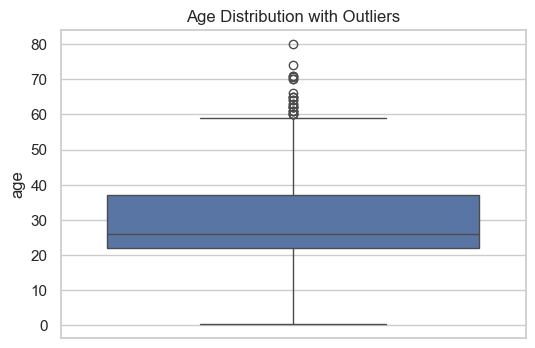

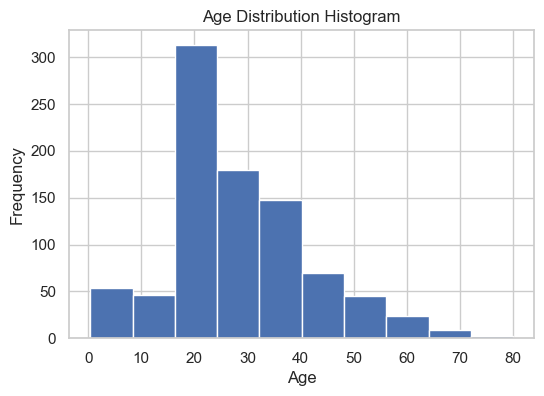

In [20]:
# Age Distribution and Outliers
plt.figure(figsize=(6,4))
sns.boxplot(y='age', data=df)
plt.title('Age Distribution with Outliers')
plt.show()

plt.figure(figsize=(6,4))
plt.hist(df['age'], bins=10)
plt.title('Age Distribution Histogram')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()


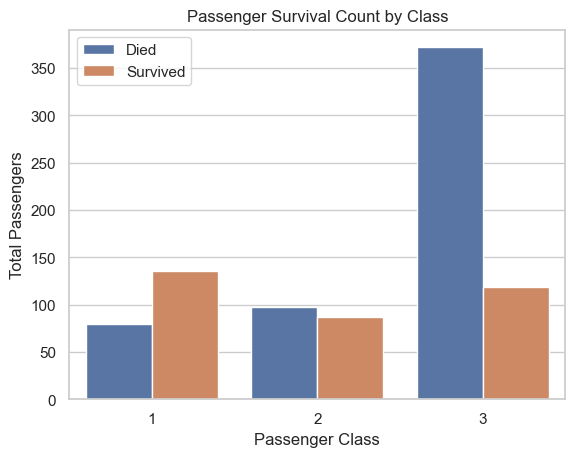

In [21]:
# Survival by Class
sns.countplot(x='pclass', hue='survived', data=df)
plt.title('Passenger Survival Count by Class')
plt.xlabel('Passenger Class')
plt.ylabel('Total Passengers')
plt.legend(labels=['Died','Survived'])
plt.show()


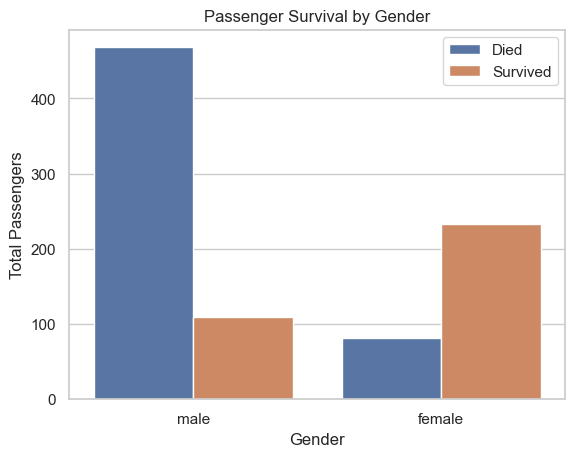

In [22]:
# Survival by Gender
sns.countplot(x='sex', hue='survived', data=df)
plt.title('Passenger Survival by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Passengers')
plt.legend(labels=['Died','Survived'])
plt.show()

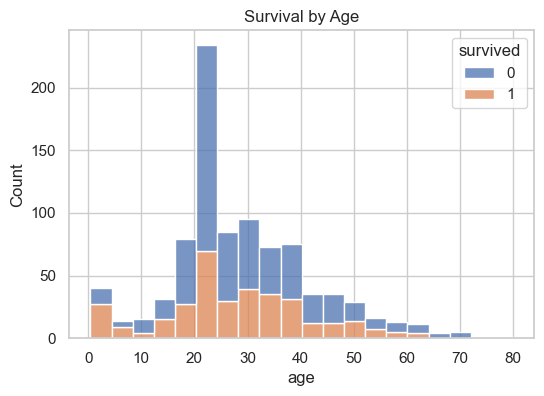

In [23]:
# Survival by Age
plt.figure(figsize=(6,4))
sns.histplot(data=df, x='age', hue='survived', multiple='stack', bins=20)
plt.title('Survival by Age')
plt.show()

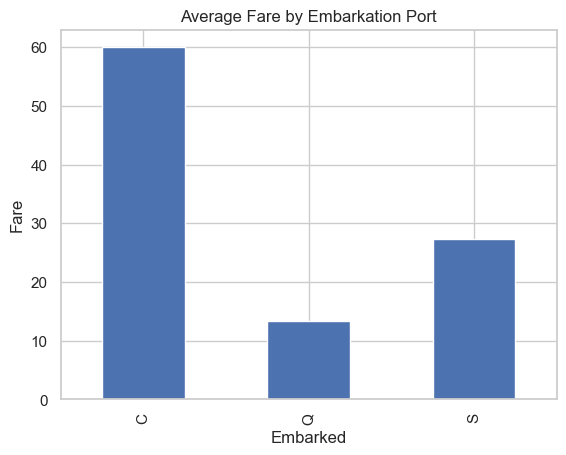

In [24]:
# Average Fare by Embarkation Port
df.groupby('embarked')['fare'].mean().plot(kind='bar')
plt.title('Average Fare by Embarkation Port')
plt.xlabel('Embarked')
plt.ylabel('Fare')
plt.show()

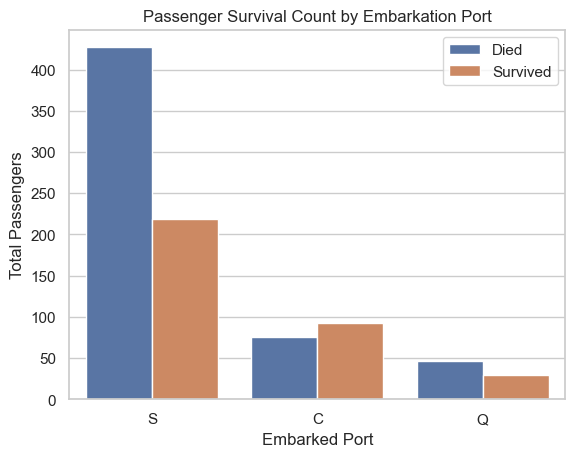

In [25]:
# Survival by Embarkation Port
sns.countplot(x='embarked', hue='survived', data=df)
plt.title('Passenger Survival Count by Embarkation Port')
plt.xlabel('Embarked Port')
plt.ylabel('Total Passengers')
plt.legend(labels=['Died','Survived'])
plt.show()

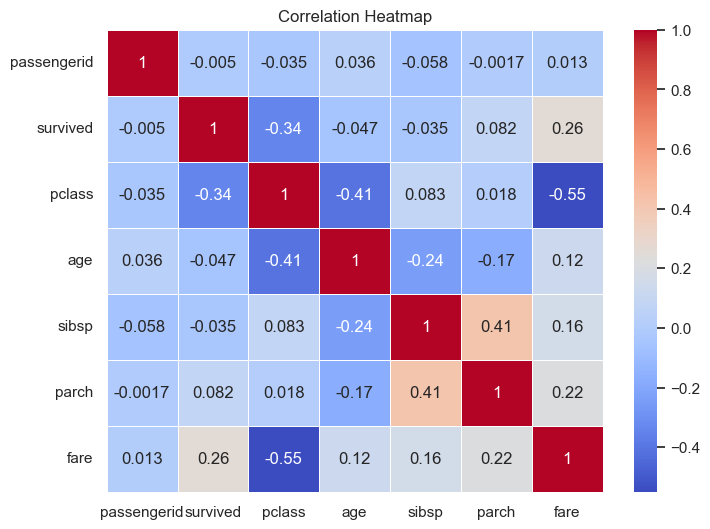

In [26]:
# Correlation Heatmap
numeric_df = df.select_dtypes(include=['number'])
plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

# Key Insights from Titanic Data Analysis:
# - 1st Class passengers had the highest survival rate.
# - Female passengers had a much higher chance of survival than males.
# - Children (especially under age 10) survived more often.
# - Passengers who paid higher fares were more likely to survive.
# - Passengers who boarded from Cherbourg (C) had higher survival chances.

# Conclusion:

# 1st-class passengers had the highest chance of survival.

# Female and younger passengers survived more often.

# Higher fares and the Cherbourg embarkation port were linked to better survival.

# Social class, gender, and wealth strongly influenced survival on the Titanic.

In [36]:
# clean data
df.to_csv("C:/Users/MAYUR MAKVANA/OneDrive/Desktop/first project/Titanic-Dataset_clean.csv")